## Spaceship Titanic Transported people Prediction
#### Workflow:
- Load Data
- EDA
- Data Preprocessing
- Feature Engineering
- Model Selection
- Model Tuning
- submission.csv

In [1]:
# Import Libreries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 

warnings.filterwarnings("ignore")

## Load Data

In [2]:
# Import and Show train Data 
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


##### Some Imp Info about the Columns
- PassengerId: gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group.
- Cabin: deck/num/side, where side can be either P for Port or S for Starboard.

##### Observations
- Passengers with CryoSleep should have 0 RoomService, FoodCourt, ShoppingMall, Spa, VRDeck Amounts.
- PassengerID = group + no of Members
- People with the same surname can be family members. So there is more chance that they are from the same planet and going to the same planet. 

In [3]:
train.shape

(8693, 14)

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 1.2+ MB


In [5]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## Exploring The Data

In [6]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
# Percentage of Missing Value per Column
(train.isnull().sum() / train.shape[0]) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

In [8]:
# Checking Duplicates
train.duplicated().sum()

np.int64(0)

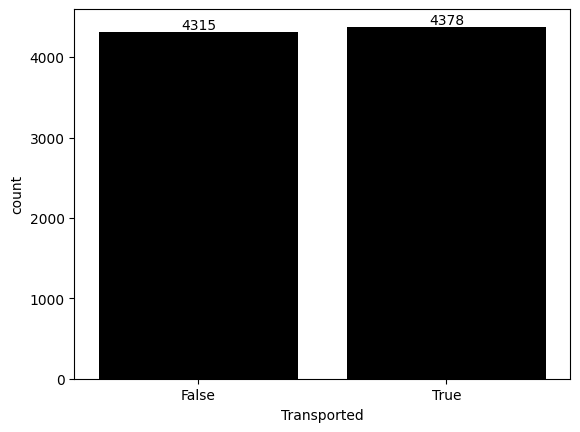

In [9]:
# Distribution of Transported Passengers
ax = sns.countplot(data = train, x = 'Transported', color = 'black')
for i in ax.containers:
    ax.bar_label(i)
plt.show()

- Ideal Distribution of Target feature

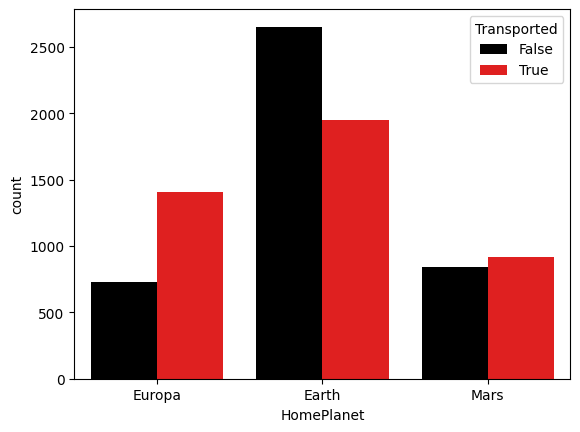

In [10]:
# Distribution of the Home planet. 
sns.countplot(
    data=train,
    x='HomePlanet',
    hue='Transported',
    palette=['black', 'red']
)

plt.show()

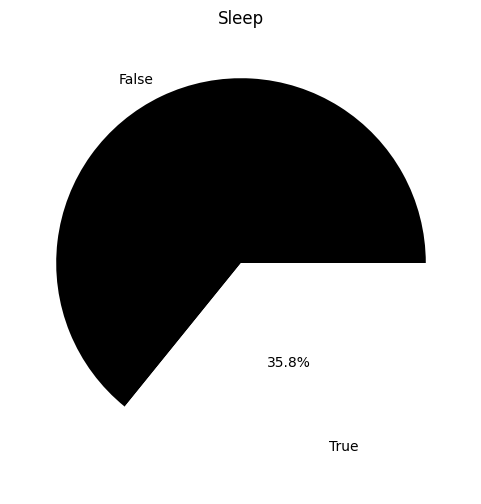

In [11]:
# Count of people with suspended animation 
plt.figure(figsize = (4, 4))
train['CryoSleep'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6), 
    colors=['black', 'white']
)

plt.title("Sleep")
plt.show()

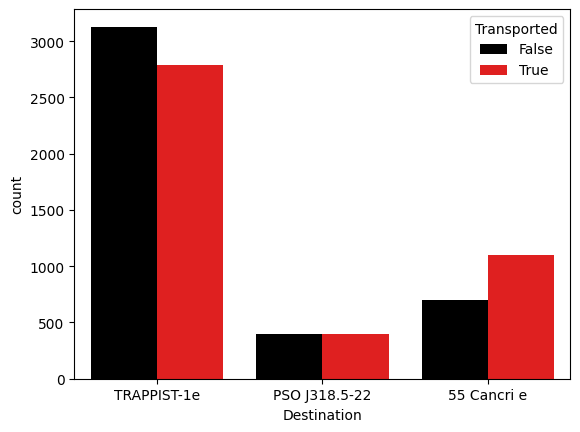

In [12]:
# Count of Destinstion
sns.countplot(
    data=train,
    x='Destination',
    hue='Transported',
    palette=['black', 'red']
)

plt.show()

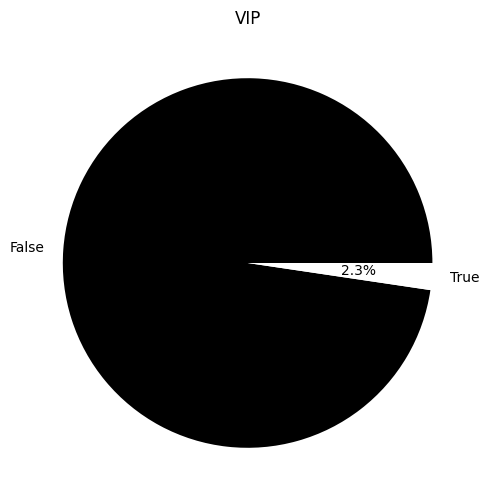

In [13]:
# VIP passangers
plt.figure(figsize = (4, 4))
train['VIP'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6, 6), 
    colors=['black', 'white']
)

plt.title("VIP")
plt.show()

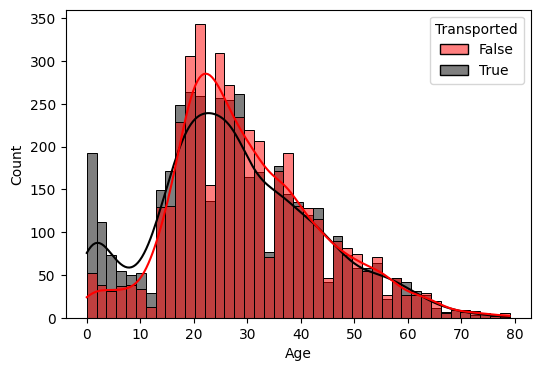

In [14]:
# Distribution of Age with transported victims
plt.figure(figsize = (6, 4))
sns.histplot(data = train, x = 'Age', kde = True, palette = ['red','black'],  hue='Transported')
plt.show()

- Most victims per age group are children and infants
#### Question:
- Verify whether people with zero age are valid or not. Maybe they are in a passenger womb or test tube babies.

**Age** = 0 in a dataset doesn't necessarily mean there were literally zero-year-old people. It could mean several things:

- Newborn infants – In medical or demographic datasets, age 0 usually represents babies who are less than 1 year old. (**ChatGpt**)
  ,So we are going to accept them as valid Data points. 

In [15]:
# No of zero-Age children
print('Children with 0 Age',len(train[train['Age'] == 0]))
print('Children with less then 5 Age',len(train[train['Age'] < 6]))

Children with 0 Age 178
Children with less then 5 Age 499


In [16]:
# Numeric Description of Different premium services
train[['RoomService', 'FoodCourt', 'ShoppingMall','Spa', 'VRDeck' ]].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,224.687617,458.077203,173.729169,311.138778,304.854791
std,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,47.000000,76.000000,27.000000,59.000000,46.000000
max,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


- Most of the luxury services are enjoyed by very few people, maybe the VIP gang. 

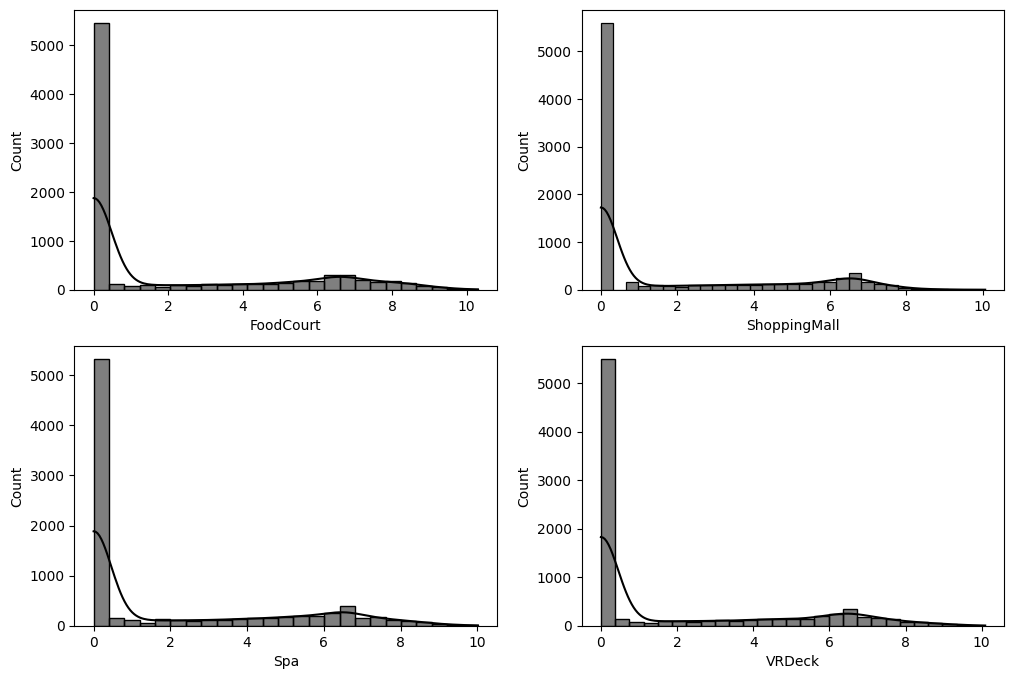

In [17]:
# Distribution of 'FoodCourt', 'ShoppingMall','Spa', 'VRDeck' service
plt.figure(figsize=(12,8))
def plotting(col, n):
    plt.subplot(2, 2, n)
    sns.histplot(np.log1p(train[col]), kde=True, color='black')

plotting('FoodCourt', 1)
plotting('ShoppingMall', 2)
plotting('Spa', 3)
plotting('VRDeck', 4)

plt.show()

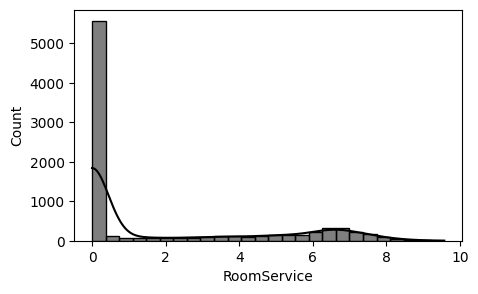

In [18]:
# Distribution of Room Service 
plt.figure(figsize = (5, 3))
sns.histplot(np.log1p(train['RoomService']), kde=True, color='black')
plt.show()

In [19]:
# Comparing VIP vs Transported victims
pd.crosstab(train['VIP'], train['Transported'])

Transported,False,True
VIP,,
False,4093,4198
True,123,76


In [20]:
# home planets vd victims
pd.crosstab(train['HomePlanet'], train['Transported'])

Transported,False,True
HomePlanet,,
Earth,2651,1951
Europa,727,1404
Mars,839,920


## Preprocessing

In [21]:
# break down the PassengerId column
train['group'] = train['PassengerId'].str.split('_').str[0]
test['group'] = train['PassengerId'].str.split('_').str[0]
print('No of Groups are', train['group'].shape[0])

No of Groups are 8693


In [22]:
# Break down the Cabin column
train[['deck', 'num', 'side']] = train['Cabin'].str.split('/', expand=True)
test[['deck', 'num', 'side']] = train['Cabin'].str.split('/', expand=True)

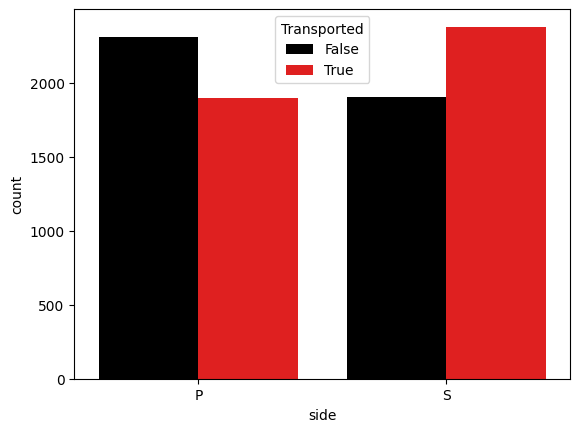

In [23]:
# Side value counts
sns.countplot(
    data=train,
    x='side',
    hue='Transported',
    palette=['black', 'red']
)

plt.show()

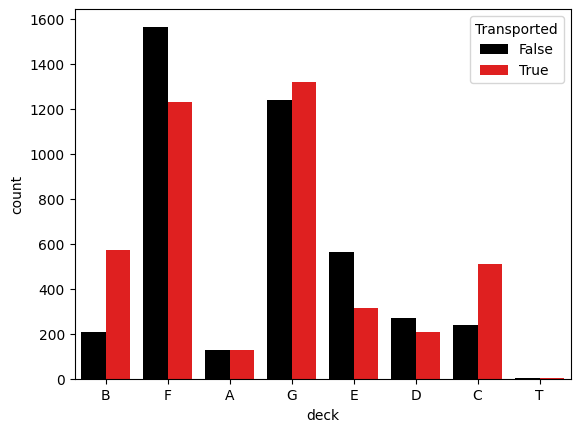

In [24]:
# Side value counts
sns.countplot(
    data=train,
    x='deck',
    hue='Transported',
    palette=['black', 'red']
)

plt.show()

In [25]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
group             0
deck            199
num             199
side            199
dtype: int64

In [26]:
# Splitting name
train[['Main_name', 'Ser_Name']] = train['Name'].str.split(' ', expand=True)
test[['Main_name', 'Ser_Name']] = train['Name'].str.split(' ', expand=True)

In [27]:
# Fill missing deck/num using other passengers with the same surname (Ser_Name)
for col in ['deck', 'num', 'side']:
    filled = train.groupby('Ser_Name')[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )
    train[col] = train[col].where(train[col].notna(), filled)

for col in ['deck', 'num', 'side']:
    filled = test.groupby('Ser_Name')[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )
    test[col] = test[col].where(test[col].notna(), filled)


- We have to fill HomePlanet, CryoSleep, Destination, Age, VIP, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, deck, num, side. 

In [28]:
# Fill the remaining NA values

# Fill NA services
services = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in services:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)
    
# Fill NA Planets
planets = ['HomePlanet', 'Destination']
for col in planets:
    train[col].fillna(train[col].mode()[0], inplace=True)
for col in planets:
    test[col].fillna(test[col].mode()[0], inplace=True)


# Fill NA CryoSleep

filled_cryo_train = train.groupby('Ser_Name')['CryoSleep'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

train['CryoSleep'] = train['CryoSleep'].fillna(filled_cryo_train)
train['CryoSleep'] = train['CryoSleep'].fillna(False)


filled_cryo_test = test.groupby('Ser_Name')['CryoSleep'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

test['CryoSleep'] = test['CryoSleep'].fillna(filled_cryo_test)
test['CryoSleep'] = test['CryoSleep'].fillna(False)


# Fill NA Age
train['Age'] = train['Age'].fillna(train['Age'].mode()[0])
test['Age'] = test['Age'].fillna(train['Age'].mode()[0])


# Fill NA VIP
train['VIP'] = train['VIP'].fillna(False)
test['VIP'] = test['VIP'].fillna(False)

# Fill remaining NA deck, num, side
cabin = ['deck', 'num', 'side']
for col in cabin:
    train[col].fillna(train[col].mode()[0], inplace=True)
for col in cabin:
    test[col].fillna(test[col].mode()[0], inplace=True)

In [29]:
# Making a group size column insted of group
train['group_size'] = train.groupby('group')['group'].transform('count')
test['group_size'] = test.groupby('group')['group'].transform('count')

<Axes: >

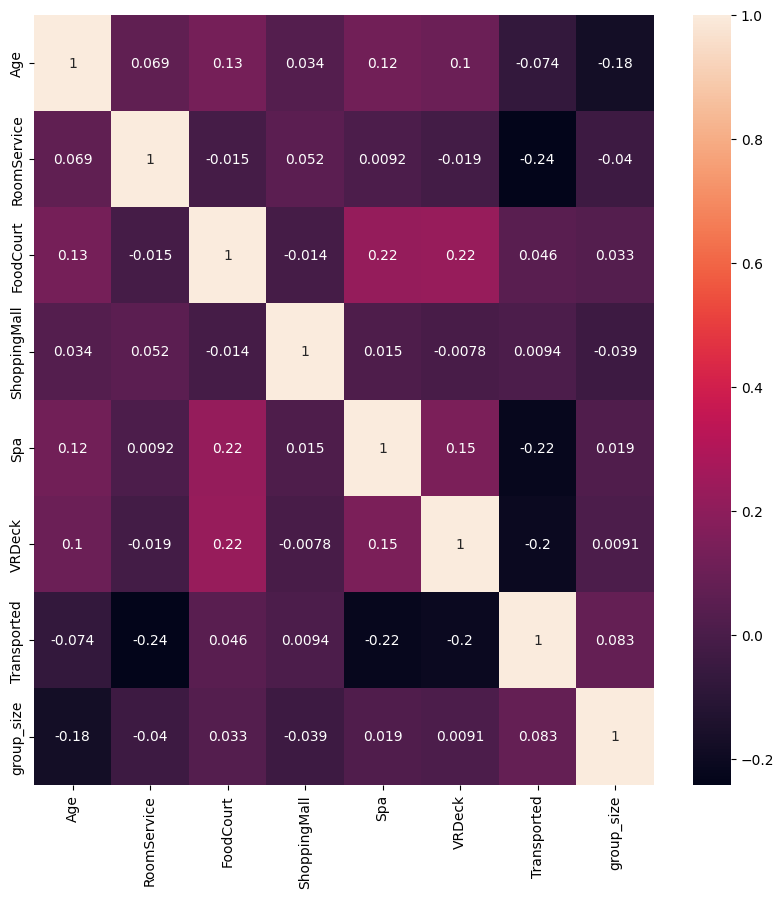

In [30]:
# Showing Correlations
plt.figure(figsize = (10,10))
sns.heatmap(train.corr(numeric_only = True), annot = True)

- Wow, cryosleep is highly associated with the transport people. The same goes for Room Service and Spa. 

## Feature Engineering

In [31]:
# Drop unrequired Column
train.drop(columns = ['Cabin','Name', 'Main_name', 'Ser_Name', 'group', 'num'], inplace = True)
test.drop(columns = ['Cabin','Name', 'Main_name', 'Ser_Name', 'group', 'num'], inplace = True)

In [32]:
cat_cols = ['HomePlanet', 'Destination', 'deck', 'side']
num_cols = [ 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'group_size']
bool_cols = ['CryoSleep', 'VIP']

# Standard Scalling on Numeric Data and One-Hot Encoding on Categorical Data. 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaling Numeric Columns
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

# Categorical Columns
train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)


# Boolean transform
train[bool_cols] = train[bool_cols].astype(int)
test[bool_cols] = test[bool_cols].astype(int)

In [33]:
train.head()

,PassengerId,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_T,side_S
0,0001_01,0,0.715553,0,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,False,...,False,True,True,False,False,False,False,False,False,False
1,0002_01,0,-0.329408,0,-0.168073,-0.275387,-0.241771,0.217158,-0.224205,True,...,False,True,False,False,False,False,True,False,False,True
2,0003_01,0,2.039169,1,-0.268001,1.959998,-0.283579,5.695623,-0.219796,False,...,False,True,False,False,False,False,False,False,False,True
3,0003_02,0,0.297569,0,-0.333105,0.523010,0.336851,2.687176,-0.092818,False,...,False,True,False,False,False,False,False,False,False,True
4,0004_01,0,-0.886720,0,0.125652,-0.237159,-0.031059,0.231374,-0.261240,True,...,False,True,False,False,False,False,True,False,False,True


## Selecting Model

In [34]:
# Import Libraries

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

X = train.drop(columns=['Transported', 'PassengerId'])
y = train['Transported']

# train, test, split
X_train, X_valid, y_train, y_valid = train_test_split( X, y, test_size=0.2,random_state=42,stratify=y )

# Models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "SVM": SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    model.fit(X_train, y_train)

    pred = model.predict(X_valid)

    acc = accuracy_score(y_valid, pred)
    prec = precision_score(y_valid, pred)
    rec = recall_score(y_valid, pred)
    f1 = f1_score(y_valid, pred)

    results[name] = acc

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

Random Forest
Accuracy : 0.8062
Precision: 0.8267
Recall   : 0.7785
F1 Score : 0.8019
XGBoost
Accuracy : 0.8097
Precision: 0.8100
Recall   : 0.8128
F1 Score : 0.8114
Logistic Regression
Accuracy : 0.7918
Precision: 0.7875
Recall   : 0.8037
F1 Score : 0.7955
SVM
Accuracy : 0.7953
Precision: 0.7989
Recall   : 0.7934
F1 Score : 0.7961


- The results of every model I use were coming so close to each other.  So let's use GridSearchCV in some of them and see. 

In [35]:
# GridSearchCV for XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6, 3],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit
grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid.best_params_)

# Best CV Accuracy
print("\nBest CV Accuracy:")
print(grid.best_score_)

# Best Model
best_xgb = grid.best_estimator_

# Validation Accuracy
pred = best_xgb.predict(X_valid)
print("Validation Accuracy:", accuracy_score(y_valid, pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}

Best CV Accuracy:
0.8037114233846567
Validation Accuracy: 0.8067855089131685


In [36]:
# GridSearchCV for Random Forest
from sklearn.svm import SVC

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1, 
    verbose = 1
)

# Fit
grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid.best_params_)

# Best CV Accuracy
print("\nBest CV Accuracy:")
print(grid.best_score_)

# Best Model
best_rf = grid.best_estimator_

# Validation Accuracy
pred = best_rf.predict(X_valid)
print("Validation Accuracy:", accuracy_score(y_valid, pred))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Best CV Accuracy:
0.8004036224650761
Validation Accuracy: 0.8033352501437608


Let's go with best_xgb model. 

## Generate submission.csv

In [37]:
# predict target feature on test Data
X = test.drop(columns=['PassengerId'])
predictions = best_xgb.predict(X)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": predictions.astype(bool)
})

# save submission.csv
submission.to_csv("submission.csv", index=False)
print(submission.head())

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
